In [1]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import pathlib
import datetime
import pandas as pd

# --- Configure folders to scan ---
FOLDERS = [
    #"/Users/kirillmaier/DocLocal/zzz_archive/Астана",
    "/Users/kirillmaier/DocLocal",
    "/Users/kirillmaier/Documents",
    "/Users/kirillmaier/Library/CloudStorage/MountainDuck-Krll2/bak_1tb",
    "/Users/kirillmaier/Library/CloudStorage/MountainDuck-Krll",
    # "/Users/kirillmaier/DocLocal/another_folder",  # add more folders here
]

RECURSIVE = True  # set False to scan top-level only


In [5]:
from tqdm.auto import tqdm


def format_int_spaces(value):
    return f"{int(value):,}".replace(",", " ")


def format_float_spaces(value, digits=2):
    formatted = f"{float(value):,.{digits}f}"
    return formatted.replace(",", " ")


def format_dt(value):
    return value.strftime("%Y-%m-%d %H:%M")


def collect_files(folders, recursive=True):
    records = []
    scanned_count = 0

    folder_iter = tqdm(folders, desc="Folders", unit="folder")
    for folder in folder_iter:
        base = pathlib.Path(folder)
        if not base.exists():
            print(f"WARNING: Folder not found: {folder}")
            continue

        path_iter = base.rglob("*") if recursive else base.glob("*")
        scan_iter = tqdm(
            path_iter,
            desc=f"Scanning {base.name}",
            unit="entry",
            leave=False,
        )

        for path in scan_iter:
            if not path.is_file():
                continue

            scanned_count += 1
            scan_iter.set_postfix(scanned_count=scanned_count)

            stat = path.stat()

            try:
                created_dt = datetime.datetime.fromtimestamp(stat.st_birthtime)
            except AttributeError:
                created_dt = datetime.datetime.fromtimestamp(stat.st_mtime)

            modified_dt = datetime.datetime.fromtimestamp(stat.st_mtime)
            records.append({
                "folder": str(base),
                "relative_path": str(path.relative_to(base)),
                "name": path.name,
                "extension": path.suffix.lower() if path.suffix else "(none)",
                "size_bytes": stat.st_size,
                "size_kb": round(stat.st_size / 1024, 2),
                "created_dt": created_dt,
                "modified_dt": modified_dt,
                "created": format_dt(created_dt),
                "modified": format_dt(modified_dt),
            })

    return pd.DataFrame(records), scanned_count


df, scanned_count = collect_files(FOLDERS, recursive=RECURSIVE)
print(f"Total files found: {format_int_spaces(len(df))}")
print(f"scanned_count: {format_int_spaces(scanned_count)}")

Folders: 100%|██████████| 4/4 [11:22<00:00, 170.70s/folder]


Total files found: 379 357
scanned_count: 379 357


In [6]:
# --- Statistics by creation month/year ---
df_stats = df.copy()
df_stats["created_month"] = df_stats["created_dt"].dt.to_period("M").astype(str)

monthly_stats = (
    df_stats.groupby("created_month")
    .agg(
        file_count=("name", "count"),
        total_size_bytes=("size_bytes", "sum"),
        avg_size_bytes=("size_bytes", "mean"),
        earliest_created=("created_dt", "min"),
        latest_created=("created_dt", "max"),
    )
    .reset_index()
    .sort_values("created_month", ascending=False)
)

current_month = datetime.datetime.now().strftime("%Y-%m")
current_month_stats = monthly_stats[monthly_stats["created_month"] == current_month].copy()

monthly_stats_display = monthly_stats.copy()
monthly_stats_display["file_count"] = monthly_stats_display["file_count"].map(format_int_spaces)
monthly_stats_display["total_size_bytes"] = monthly_stats_display["total_size_bytes"].map(format_int_spaces)
monthly_stats_display["avg_size_bytes"] = monthly_stats_display["avg_size_bytes"].map(lambda value: format_float_spaces(value, 0))
monthly_stats_display["earliest_created"] = monthly_stats_display["earliest_created"].map(format_dt)
monthly_stats_display["latest_created"] = monthly_stats_display["latest_created"].map(format_dt)

total_bytes = df["size_bytes"].sum()
print(
    f"Total size: {format_int_spaces(total_bytes)} bytes  |  "
    f"Files: {format_int_spaces(len(df))}  |  "
    f"Months: {format_int_spaces(len(monthly_stats))}"
)
print(f"Current month: {current_month}")

if current_month_stats.empty:
    print("Current month stats: 0 files")
else:
    month_row = current_month_stats.iloc[0]
    print(
        "Current month stats: "
        f"files={format_int_spaces(month_row['file_count'])}, "
        f"total_size_bytes={format_int_spaces(month_row['total_size_bytes'])}, "
        f"avg_size_bytes={format_float_spaces(month_row['avg_size_bytes'], 0)}"
    )

display(monthly_stats_display)


Total size: 613 570 227 259 bytes  |  Files: 379 357  |  Months: 343
Current month: 2026-04
Current month stats: files=12 117, total_size_bytes=261 150 997, avg_size_bytes=21 552


,created_month,file_count,total_size_bytes,avg_size_bytes,earliest_created,latest_created
342,2026-04,12 117,261 150 997,21 552,2026-04-01 21:28,2026-04-07 21:17
341,2026-03,1 264,116 438 097,92 119,2026-03-01 03:01,2026-03-31 23:17
340,2026-02,4 007,307 105 953,76 642,2026-02-01 14:30,2026-02-28 21:09
339,2026-01,1 351,264 021 977,195 427,2026-01-01 01:33,2026-01-30 21:01
338,2025-12,1 605,150 216 181 075,93 592 636,2025-12-02 11:42,2025-12-31 23:31
...,...,...,...,...,...,...
4,1994-06,1,53 248,53 248,1994-06-20 06:26,1994-06-20 06:26
3,1993-06,1,1 048 576,1 048 576,1993-06-28 13:13,1993-06-28 13:13
2,1990-01,2,3 750,1 875,1990-01-01 16:01,1990-01-01 16:01
1,1984-01,3,1 342 177 280,447 392 427,1984-01-24 14:00,1984-01-24 14:00


In [7]:
# --- Full index sorted by creation date (newest first) ---
df_sorted = df.sort_values("created_dt", ascending=False).reset_index(drop=True)

df_display = df_sorted.copy()
df_display["size_bytes"] = df_display["size_bytes"].map(format_int_spaces)
df_display["size_kb"] = df_display["size_kb"].map(lambda value: format_float_spaces(value, 2))
df_display = df_display[[
    "folder",
    "relative_path",
    "name",
    "extension",
    "size_bytes",
    "size_kb",
    "created",
    "modified",
]]

# Uncomment to export raw data:
# df_sorted.to_csv("/Users/kirillmaier/DocLocal/files_index.csv", index=False)

#display(df_display)


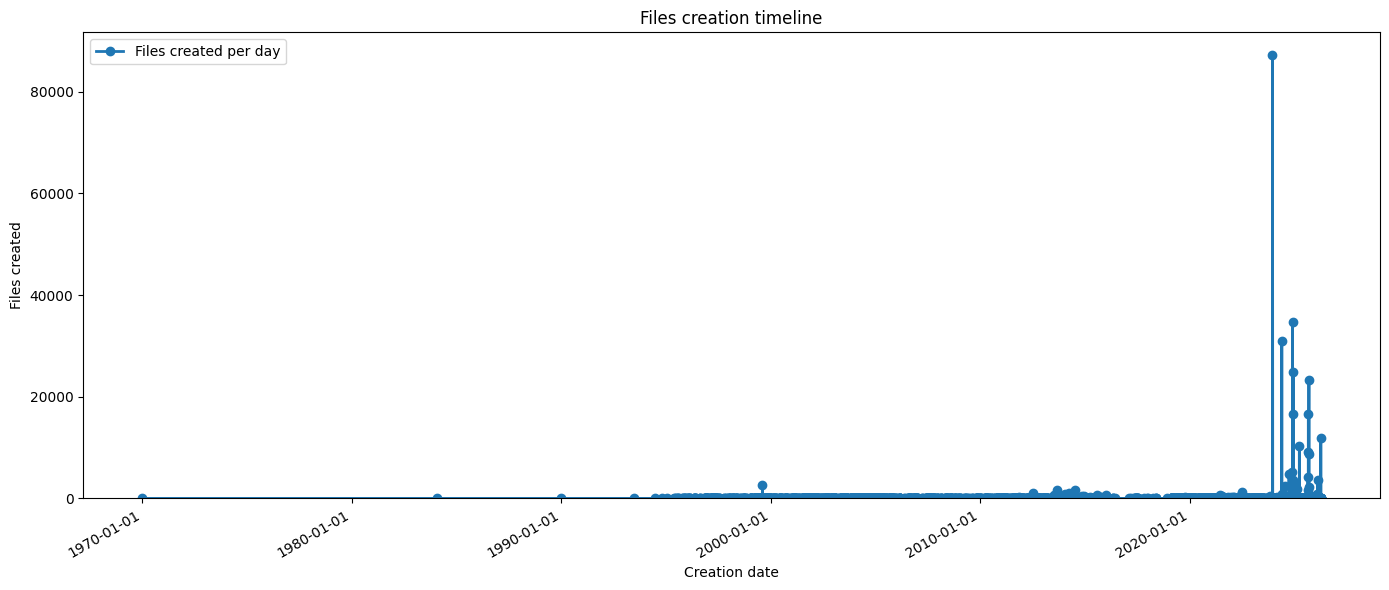

,created_day,file_count
0,1970-01-01,1
1,1984-01-24,3
2,1990-01-01,2
3,1993-06-28,1
4,1994-06-20,1
...,...,...
2920,2026-04-03,11957
2921,2026-04-04,28
2922,2026-04-05,14
2923,2026-04-06,3


In [8]:
# --- Timeline of file creation ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

creation_timeline = df.copy().sort_values("created_dt")
creation_timeline["created_day"] = creation_timeline["created_dt"].dt.floor("D")

daily_created = (
    creation_timeline.groupby("created_day")
    .size()
    .reset_index(name="file_count")
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    daily_created["created_day"],
    daily_created["file_count"],
    marker="o",
    linewidth=2,
    color="#1f77b4",
    label="Files created per day",
)
ax.bar(
    daily_created["created_day"],
    daily_created["file_count"],
    width=0.8,
    alpha=0.2,
    color="#1f77b4",
)

ax.set_title("Files creation timeline")
ax.set_xlabel("Creation date")
ax.set_ylabel("Files created")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate(rotation=30)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

display(daily_created)


In [9]:
# --- Fast duplicate files finder (same content) ---
import hashlib


def file_sha256(path, chunk_size=1024 * 1024):
    hasher = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()


def head_sha256(path, head_bytes=64 * 1024):
    hasher = hashlib.sha256()
    with open(path, "rb") as f:
        hasher.update(f.read(head_bytes))
    return hasher.hexdigest()


dup_df = df.copy()
dup_df["full_path"] = dup_df.apply(
    lambda row: str(pathlib.Path(row["folder"]) / row["relative_path"]),
    axis=1,
)

# Stage 1: only same-size files can be true duplicates
size_candidates = dup_df[dup_df.duplicated("size_bytes", keep=False)].copy()
print(f"Same-size candidate files: {format_int_spaces(len(size_candidates))}")

if size_candidates.empty:
    duplicate_files = pd.DataFrame()
    print("No duplicate files found.")
else:
    # Stage 2: hash only first 64KB to reduce expensive full-file hashing
    size_candidates["head_hash"] = size_candidates["full_path"].map(head_sha256)
    quick_candidates = size_candidates[
        size_candidates.duplicated(["size_bytes", "head_hash"], keep=False)
    ].copy()
    print(f"Quick-hash candidate files: {format_int_spaces(len(quick_candidates))}")

    if quick_candidates.empty:
        duplicate_files = pd.DataFrame()
        print("No duplicate files found.")
    else:
        # Stage 3: full hash only for remaining candidates
        quick_candidates["full_hash"] = quick_candidates["full_path"].map(file_sha256)
        duplicate_files = quick_candidates[
            quick_candidates.duplicated(["size_bytes", "full_hash"], keep=False)
        ].copy()

        if duplicate_files.empty:
            print("No duplicate files found.")
        else:
            duplicate_files = duplicate_files.sort_values(
                ["size_bytes", "full_hash", "full_path"],
                ascending=[False, True, True],
            ).reset_index(drop=True)
            duplicate_files["duplicate_group"] = (
                duplicate_files.groupby(["size_bytes", "full_hash"]).ngroup() + 1
            )
            duplicate_files["copies_in_group"] = duplicate_files.groupby(
                ["size_bytes", "full_hash"]
            )["full_path"].transform("count")

            duplicate_files_display = duplicate_files[[
                "duplicate_group",
                "copies_in_group",
                "size_bytes",
                "created",
                "full_path",
            ]].copy()
            duplicate_files_display["size_bytes"] = duplicate_files_display["size_bytes"].map(format_int_spaces)

            wasted_bytes = (
                duplicate_files.groupby(["size_bytes", "full_hash"])["size_bytes"]
                .first()
                .mul(
                    duplicate_files.groupby(["size_bytes", "full_hash"])["full_path"].count() - 1
                )
                .sum()
            )

            print(
                f"Duplicate groups: {format_int_spaces(duplicate_files['duplicate_group'].nunique())}  |  "
                f"Duplicate files: {format_int_spaces(len(duplicate_files))}  |  "
                f"Wasted bytes: {format_int_spaces(wasted_bytes)}"
            )
            display(duplicate_files_display)


Same-size candidate files: 349 621


TimeoutError: [Errno 60] Operation timed out

In [10]:
# --- Top 20 heaviest files ---
top20_heavy = df.copy().sort_values("size_bytes", ascending=False).head(20).reset_index(drop=True)
top20_heavy["full_path"] = top20_heavy.apply(
    lambda row: str(pathlib.Path(row["folder"]) / row["relative_path"]),
    axis=1,
)

top20_heavy_display = top20_heavy[[
    "size_bytes",
    "size_kb",
    "created",
    "modified",
    "extension",
    "full_path",
]].copy()

top20_heavy_display["size_bytes"] = top20_heavy_display["size_bytes"].map(format_int_spaces)
top20_heavy_display["size_kb"] = top20_heavy_display["size_kb"].map(lambda value: format_float_spaces(value, 2))

print(f"Top heavy files shown: {format_int_spaces(len(top20_heavy_display))}")
display(top20_heavy_display)


Top heavy files shown: 20


,size_bytes,size_kb,created,modified,extension,full_path
0,145 776 683 726,142 360 042.70,2025-12-02 12:51,2025-12-02 12:51,.zip,/Users/kirillmaier/Library/CloudStorage/Mounta...
1,115 346 447 206,112 643 014.85,2024-12-08 18:33,2024-12-08 18:33,.zip,/Users/kirillmaier/Library/CloudStorage/Mounta...
2,28 495 167 673,27 827 312.18,2024-12-08 17:40,2024-12-08 17:56,.zip,/Users/kirillmaier/DocLocal/edu/English/Oxford...
3,18 519 423 421,18 085 374.43,2024-09-22 19:31,2024-09-22 19:31,.7z,/Users/kirillmaier/DocLocal/zzz_archive/яя3333...
4,4 862 509 056,4 748 544.00,2023-12-13 22:29,2017-12-28 23:53,.part,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...
5,4 861 917 909,4 747 966.71,2023-12-13 22:40,2017-12-27 13:45,.zip,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...
6,4 808 835 072,4 696 128.00,2023-12-13 22:38,2017-12-28 23:53,.part,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...
7,4 727 898 112,4 617 088.00,2023-12-13 22:36,2017-12-28 23:52,.part,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...
8,4 673 699 840,4 564 160.00,2023-12-13 22:27,2017-12-28 23:52,.part,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...
9,4 273 274 880,4 173 120.00,2023-12-13 22:34,2017-12-28 23:53,.part,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...


In [12]:
# --- Biggest equal directory sets across all levels (ignore folder names, keep file names) ---
from collections import defaultdict, Counter


def tree_signature_from_parts(file_name_size_pairs, child_signatures):
    # Folder names are ignored. File names are kept to avoid false positives.
    files_counter = tuple(sorted(Counter(file_name_size_pairs).items()))
    child_counter = tuple(sorted(Counter(child_signatures).items()))
    return (files_counter, child_counter)


all_dirs = []
for root in FOLDERS:
    root_path = pathlib.Path(root)
    if not root_path.exists() or not root_path.is_dir():
        print(f"WARNING: Root folder not found: {root}")
        continue

    all_dirs.append(root_path)
    all_dirs.extend([p for p in root_path.rglob("*") if p.is_dir()])

# De-duplicate paths if configured roots overlap.
all_dirs = sorted({p.resolve() for p in all_dirs})
print(f"Directories scanned: {format_int_spaces(len(all_dirs))}")

if not all_dirs:
    equal_dir_groups = pd.DataFrame()
    equal_dir_members = pd.DataFrame()
    print("No directories found under selected roots.")
else:
    dir_signature = {}
    dir_file_count = {}
    dir_total_size = {}
    skipped_files = 0

    # Bottom-up: if children are equal, parents can also become equal.
    dirs_bottom_up = sorted(all_dirs, key=lambda p: len(p.parts), reverse=True)

    for d in dirs_bottom_up:
        try:
            entries = list(d.iterdir())
        except OSError:
            entries = []

        direct_files = [p for p in entries if p.is_file()]
        direct_subdirs = [p for p in entries if p.is_dir()]

        file_name_size_pairs = []
        files_count = 0
        total_size = 0

        for f in sorted(direct_files):
            try:
                size = f.stat().st_size
            except OSError:
                skipped_files += 1
                continue

            # Include filename + size. Content hash is intentionally not used.
            file_name_size_pairs.append((f.name, size))
            files_count += 1
            total_size += size

        child_signatures = []
        for child in sorted(direct_subdirs):
            child = child.resolve()
            child_sig = dir_signature.get(child, ((), ()))
            child_signatures.append(child_sig)
            files_count += dir_file_count.get(child, 0)
            total_size += dir_total_size.get(child, 0)

        # Ignore folder names by using only child subtree signatures.
        signature = tree_signature_from_parts(file_name_size_pairs, child_signatures)
        dir_signature[d] = signature
        dir_file_count[d] = files_count
        dir_total_size[d] = total_size

    if skipped_files:
        print(f"Skipped files (stat/read error): {format_int_spaces(skipped_files)}")

    signature_groups = defaultdict(list)
    for d in all_dirs:
        signature_groups[dir_signature[d]].append(d)

    group_rows = []
    for _, dirs in signature_groups.items():
        if len(dirs) < 2:
            continue

        sample = dirs[0]
        files_in_tree = dir_file_count[sample]
        total_size_bytes = dir_total_size[sample]

        # Skip empty-only groups to focus on meaningful equal sets.
        if files_in_tree == 0:
            continue

        group_rows.append({
            "folders_in_group": len(dirs),
            "files_in_tree": files_in_tree,
            "total_size_bytes": total_size_bytes,
            "members": [str(x) for x in sorted(dirs)],
        })

    if not group_rows:
        equal_dir_groups = pd.DataFrame()
        equal_dir_members = pd.DataFrame()
        print("No fully equal directory sets found.")
    else:
        equal_dir_groups = pd.DataFrame(group_rows).sort_values(
            ["total_size_bytes", "folders_in_group", "files_in_tree"],
            ascending=[False, False, False],
        ).reset_index(drop=True)
        equal_dir_groups["equal_set_id"] = equal_dir_groups.index + 1

        member_rows = []
        for _, row in equal_dir_groups.iterrows():
            for folder in row["members"]:
                member_rows.append({
                    "equal_set_id": row["equal_set_id"],
                    "folders_in_group": row["folders_in_group"],
                    "files_in_tree": row["files_in_tree"],
                    "total_size_bytes": row["total_size_bytes"],
                    "parent_folder": str(pathlib.Path(folder).parent),
                    "folder": folder,
                })

        equal_dir_members = pd.DataFrame(member_rows).sort_values(
            ["total_size_bytes", "equal_set_id", "folder"],
            ascending=[False, True, True],
        ).reset_index(drop=True)

        groups_display = equal_dir_groups[[
            "equal_set_id",
            "folders_in_group",
            "files_in_tree",
            "total_size_bytes",
        ]].copy()
        groups_display["folders_in_group"] = groups_display["folders_in_group"].map(format_int_spaces)
        groups_display["files_in_tree"] = groups_display["files_in_tree"].map(format_int_spaces)
        groups_display["total_size_bytes"] = groups_display["total_size_bytes"].map(format_int_spaces)

        members_display = equal_dir_members[[
            "equal_set_id",
            "folders_in_group",
            "files_in_tree",
            "total_size_bytes",
            "parent_folder",
            "folder",
        ]].copy()
        members_display["folders_in_group"] = members_display["folders_in_group"].map(format_int_spaces)
        members_display["files_in_tree"] = members_display["files_in_tree"].map(format_int_spaces)
        members_display["total_size_bytes"] = members_display["total_size_bytes"].map(format_int_spaces)

        print(
            f"Equal sets found: {format_int_spaces(len(equal_dir_groups))}  |  "
            f"Folders matched: {format_int_spaces(len(equal_dir_members))}"
        )
        display(groups_display)
        display(members_display)


Directories scanned: 42 147
Equal sets found: 8 181  |  Folders matched: 25 853


,equal_set_id,folders_in_group,files_in_tree,total_size_bytes
0,1,2,184,2 284 852 757
1,2,2,64,166 693 888
2,3,2,10,163 586 052
3,4,2,2 270,162 248 165
4,5,2,23,139 637 143
...,...,...,...,...
8176,8177,2,1,0
8177,8178,2,1,0
8178,8179,2,1,0
8179,8180,2,1,0


,equal_set_id,folders_in_group,files_in_tree,total_size_bytes,parent_folder,folder
0,1,2,184,2 284 852 757,/Users/kirillmaier/DocLocal/photos,/Users/kirillmaier/DocLocal/photos/Космостанци...
1,1,2,184,2 284 852 757,/Users/kirillmaier/Library/CloudStorage/Mounta...,/Users/kirillmaier/Library/CloudStorage/Mounta...
2,2,2,64,166 693 888,/Users/kirillmaier/DocLocal/games/save_bak/PS4...,/Users/kirillmaier/DocLocal/games/save_bak/PS4...
3,2,2,64,166 693 888,/Users/kirillmaier/DocLocal/games/save_bak/PS4...,/Users/kirillmaier/DocLocal/games/save_bak/PS4...
4,3,2,10,163 586 052,/Users/kirillmaier/DocLocal/games/RetroArch/games,/Users/kirillmaier/DocLocal/games/RetroArch/ga...
...,...,...,...,...,...,...
25848,8179,2,1,0,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...
25849,8180,2,1,0,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...
25850,8180,2,1,0,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...,/Users/kirillmaier/DocLocal/bak_1tb/transfer-h...
25851,8181,2,1,0,/Users/kirillmaier/DocLocal/prog/local-files-i...,/Users/kirillmaier/DocLocal/prog/local-files-i...


In [13]:
members_display.to_csv("Biggest equal directory sets across all levels (names ignored)_moundet_dirs.csv", index=False)